In [ ]:
!pip install langgraph
!pip install langchain
!pip install langsmith
!pip install langchain_groq
!pip install python-dotenv

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

In [ ]:
from langchain_groq import ChatGroq

model = ChatGroq(model="llama-3.1-8b-instant", api_key=GROQ_API_KEY, streaming=True)

## Building basic chatbot with Langgraph

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END # these are StateGraph, START, END we talked in previous notebook
from langgraph.graph import add_messages # this is called reducers

Basically these add_messages is called reducers, basically we can call our StateGraph as many times as we want suppose I called it my StateGraph of basic chatbot two times:

<pre>
User : Hi
Bot : Hello!

User : How are you
Bot : I'm doing well!
</pre>

now we can store these messages in the list without replacing the older once
<pre>
[
    HumanMessage("Hi"),
    AIMessage("Hello!"),
    HumanMessage("How are you?"),
    AIMessage("I'm doing well!")
]
</pre>
So that we can maintain this information and that's the reason we say it a StateGraph

So to append this into the list we use reducers, there can be many reducers one of them is "add_messages"

Let's create our state

In [ ]:
class State(TypedDict):
  messages : Annotated[list, add_messages]

Let's create Graph builder

In [ ]:
graph_builder = StateGraph(State)

Now we have to create a Node Definition to add this node to our graph

In [ ]:
def chatbot(state:State):
  return {"messages" : [model.invoke(state["messages"])]}

Basically as soon as our messages comes in the list like first our input message will come then it will generate and keep appending in the list

Now we create Graph with graph builder

In [ ]:
# Adding Node to graph
graph_builder.add_node("chatbot", chatbot) # This "chatbot" can be any name but next parameter must be the definition of the node

# Adding Edges
graph_builder.add_edge(START, "chatbot") # Now as we can see our graph start from "START" and then nodes come in between then "END" so this is like a workflow
graph_builder.add_edge("chatbot", END)

# Compile the graph
graph = graph_builder.compile()

Visualize the graph

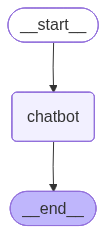

In [ ]:
from IPython.display import Image, display # Display function is responsible for displaying the graph and we pass a image object in it so we also use Image

try:
  display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
  print("Cannot draw the graph")

In [ ]:
response = graph.invoke({"messages" : "Hi"})

In [ ]:
response

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='73dd1d3f-9e7e-4375-8afd-d7e15c36d335'),
  AIMessage(content='How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 36, 'total_tokens': 44, 'completion_time': 0.009126525, 'completion_tokens_details': None, 'prompt_time': 0.002001868, 'prompt_tokens_details': None, 'queue_time': 0.055311791, 'total_time': 0.011128393}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f382a-c592-7612-9d12-1648902be8d5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 8, 'total_tokens': 44})]}

Let's stream it

In [ ]:
for event in graph.stream({"messages" : "Write an essay on AI of 40 words"}):
  for value in event.values():
    print(value["messages"][-1].content)

Artificial Intelligence (AI) has revolutionized the world with its ability to learn, reason, and interact. From virtual assistants to self-driving cars, AI has become an integral part of our lives. Its potential to solve complex problems and improve efficiency continues to grow.


Now here in this code graph.stream() yields events one by one, instead of waiting for the entire graph to finish, everytime a node in the graph is finishes, event is returned, like

<pre>
Graph
 │
 ├── Node A finishes  ---> event 1
 │
 ├── Node B finishes  ---> event 2
 │
 ├── Node C finishes  ---> event 3
 │
 Done
</pre>



Also in the second loop event is actually a dictionary

<pre>
event = {
    "chatbot": {
        "messages": [
            HumanMessage(...),
            AIMessage(...)
        ]
    }
}
</pre>

so event.values() returns

<pre>
[
    {
        "messages": [...]
    }
]
</pre>

If our graph have multiple nodes like

<pre>
event = {
    "chatbot": {...},
    "summarizer": {...}
}
</pre>

then event.values() looks like

<pre>
[
    {"messages": [...]},
    {"messages": [...]}
]
</pre>
Basically it goes through every node's output,

and we saw after running above cell our text directly came instead of streaming its because graph.stream() streams graph event, not LLM tokens and our graph have only 1 node thats why when it finished its output came and it ended..


If we want to stream tokens we can put "streaming=True" in our llm initialization at the top, then use langgraph stream mode for messages

In [ ]:
for chunk, metadata in graph.stream(
    {"messages" : "Write an essay on AI in 50 words"},
    stream_mode="messages"):

  print(chunk.content, end="", flush=True)


Art
ificial
 Intelligence
 (
AI
)
 has
 revolution
ized
 the
 world
 with
 its
 capabilities
 in
 machine
 learning
,
 natural
 language
 processing
,
 and
 computer
 vision
.
 AI
 systems
 can
 now
 perform
 tasks
 autonom
ously
,
 providing
 insights
 and
 solutions
 to
 complex
 problems
.
 Its
 applications
 range
 from
 healthcare
 and
 finance
 to
 education
 and
 entertainment
,
 enhancing
 human
 life
 and
 driving
 innovation
.




Basically flush=True is used to tell python dont use buffer, with buffer python stores everything in the buffer and send everything to terminal when finished but with flush=True it instantly sends to the terminal and shows instantly without using buffer